In [1]:
# ── FILE: notebooks/02_modeling.ipynb | CELL 1 ───────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os

warnings.filterwarnings('ignore')
os.makedirs('../models', exist_ok=True)
os.makedirs('../docs',   exist_ok=True)

plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.grid']      = True
plt.rcParams['grid.alpha']     = 0.3
sns.set_theme(style='whitegrid')

print("✅ Cell 1 — Import selesai")

✅ Cell 1 — Import selesai


In [2]:
# ── FILE: notebooks/02_modeling.ipynb | CELL 2 ───────────
from sklearn.preprocessing import MinMaxScaler

df = pd.read_csv('../data/all_stocks_5yr.csv', parse_dates=['date'])

print(f"Total baris   : {len(df):,}")
print(f"Saham unik    : {df['Name'].nunique()}")
print(f"Rentang waktu : {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Kolom         : {list(df.columns)}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print("\n✅ Cell 2 — Data loaded")

Total baris   : 619,040
Saham unik    : 505
Rentang waktu : 2013-02-08 → 2018-02-07
Kolom         : ['date', 'open', 'high', 'low', 'close', 'volume', 'Name']

Missing values:
date       0
open      11
high       8
low        8
close      0
volume     0
Name       0
dtype: int64

✅ Cell 2 — Data loaded


In [3]:
# ── FILE: notebooks/02_modeling.ipynb | CELL 3 ───────────
STOCK = 'AAPL'

stock_df = (df[df['Name'] == STOCK]
            .copy()
            .sort_values('date')
            .reset_index(drop=True))

print(f"Data {STOCK}: {len(stock_df)} baris")

def build_features(d):
    d = d.copy()

    for lag in [1, 2, 3, 5]:
        d[f'close_lag{lag}'] = d['close'].shift(lag)

    d['MA5']  = d['close'].rolling(5).mean()
    d['MA10'] = d['close'].rolling(10).mean()
    d['MA20'] = d['close'].rolling(20).mean()

    d['volatility']   = d['close'].rolling(10).std()
    d['price_range']  = d['high'] - d['low']
    d['daily_return'] = d['close'].pct_change()

    delta = d['close'].diff()
    gain  = delta.clip(lower=0).rolling(14).mean()
    loss  = (-delta.clip(upper=0)).rolling(14).mean()
    rs    = gain / loss.replace(0, np.nan)
    d['RSI'] = 100 - (100 / (1 + rs))
    d['RSI'] = d['RSI'].fillna(50)

    return d.dropna().reset_index(drop=True)

data = build_features(stock_df)

print(f"Shape setelah feature engineering : {data.shape}")
print("✅ Cell 3 — Feature engineering selesai")

Data AAPL: 1259 baris
Shape setelah feature engineering : (1240, 18)
✅ Cell 3 — Feature engineering selesai


In [4]:
# ── FILE: notebooks/02_modeling.ipynb | CELL 4 ───────────
FEATURES = [
    'open', 'high', 'low', 'volume',
    'close_lag1', 'close_lag2', 'close_lag3', 'close_lag5',
    'MA5', 'MA10', 'MA20',
    'volatility', 'price_range', 'daily_return', 'RSI'
]
TARGET = 'close'

X     = data[FEATURES].values
y     = data[TARGET].values
dates = data['date'].values

n       = len(X)
n_train = int(n * 0.70)
n_val   = int(n * 0.15)

X_train = X[:n_train]
y_train = y[:n_train]
X_val   = X[n_train : n_train + n_val]
y_val   = y[n_train : n_train + n_val]
X_test  = X[n_train + n_val:]
y_test  = y[n_train + n_val:]
dates_test = dates[n_train + n_val:]

print(f"Train : {X_train.shape}")
print(f"Val   : {X_val.shape}")
print(f"Test  : {X_test.shape}")

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_sc = scaler_X.fit_transform(X_train)
X_val_sc   = scaler_X.transform(X_val)
X_test_sc  = scaler_X.transform(X_test)

y_train_sc = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()
y_val_sc   = scaler_y.transform(y_val.reshape(-1, 1)).ravel()
y_test_sc  = scaler_y.transform(y_test.reshape(-1, 1)).ravel()

joblib.dump(scaler_X, '../models/scaler_X.pkl')
joblib.dump(scaler_y, '../models/scaler_y.pkl')

results = {}  # ← dict perbandingan semua model

print("✅ Cell 4 — Split & scaling selesai")
print("✅ Scaler tersimpan di models/")

Train : (868, 15)
Val   : (186, 15)
Test  : (186, 15)
✅ Cell 4 — Split & scaling selesai
✅ Scaler tersimpan di models/


In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ── Training ──────────────────────────────────────────────
lr = LinearRegression()
lr.fit(X_train_sc, y_train)

# ── Prediksi ──────────────────────────────────────────────
y_pred_lr = lr.predict(X_test_sc)

# ── Metrik evaluasi ───────────────────────────────────────
mae_lr  = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr   = r2_score(y_test, y_pred_lr)
mape_lr = np.mean(np.abs((y_test - y_pred_lr) / y_test)) * 100

print("=" * 38)
print("   LINEAR REGRESSION — TEST RESULT")
print("=" * 38)
print(f"   MAE  : {mae_lr:.4f}")
print(f"   RMSE : {rmse_lr:.4f}")
print(f"   R²   : {r2_lr:.4f}")
print(f"   MAPE : {mape_lr:.2f}%")
print("=" * 38)

print("Prediksi min:", y_pred_lr.min())
print("Prediksi max:", y_pred_lr.max())
print("Aktual min  :", y_test.min())
print("Aktual max  :", y_test.max())

# Simpan model
joblib.dump(lr, "../models/linear_regression.pkl")
print("✅ Model tersimpan: models/linear_regression.pkl")

results = {}
results["Linear Regression"] = {
    "MAE": round(mae_lr, 4),
    "RMSE": round(rmse_lr, 4),
    "R2": round(r2_lr, 4),
    "MAPE": round(mape_lr, 2)
}

   LINEAR REGRESSION — TEST RESULT
   MAE  : 0.3958
   RMSE : 0.5673
   R²   : 0.9968
   MAPE : 0.24%
Prediksi min: 142.8364568383122
Prediksi max: 179.150040755006
Aktual min  : 142.27
Aktual max  : 179.26
✅ Model tersimpan: models/linear_regression.pkl


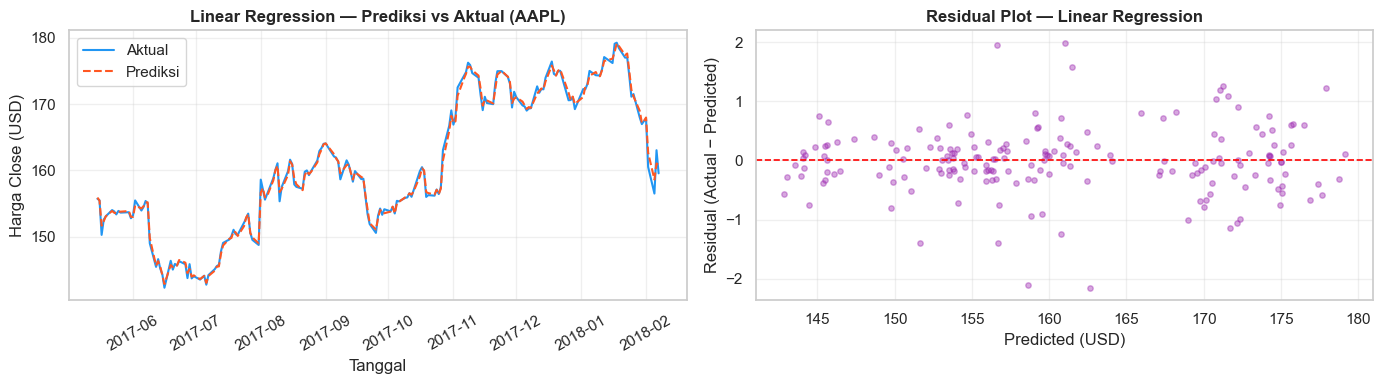

✅ Cell 6 — Grafik tersimpan: docs/lr_results.png


In [6]:
# ── FILE: notebooks/02_modeling.ipynb | CELL 6 ───────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(dates_test, y_test,
             label='Aktual',   color='#2196F3', linewidth=1.5)
axes[0].plot(dates_test, y_pred_lr,
             label='Prediksi', color='#FF5722',
             linewidth=1.5, linestyle='--')
axes[0].set_title(f'Linear Regression — Prediksi vs Aktual ({STOCK})',
                  fontweight='bold')
axes[0].set_xlabel('Tanggal')
axes[0].set_ylabel('Harga Close (USD)')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=30)

residuals = y_test - y_pred_lr
axes[1].scatter(y_pred_lr, residuals,
                alpha=0.4, color='#9C27B0', s=15)
axes[1].axhline(0, color='red', linewidth=1.2, linestyle='--')
axes[1].set_title('Residual Plot — Linear Regression', fontweight='bold')
axes[1].set_xlabel('Predicted (USD)')
axes[1].set_ylabel('Residual (Actual − Predicted)')

plt.tight_layout()
plt.savefig('../docs/lr_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Cell 6 — Grafik tersimpan: docs/lr_results.png")

In [7]:
# ── FILE: notebooks/02_modeling.ipynb | CELL 7 (REVISI) ──
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

tf.random.set_seed(42)
np.random.seed(42)

# ── Cek range data untuk debug ────────────────────────────
print("=== CEK RANGE DATA ===")
print(f"y_train_sc : min={y_train_sc.min():.4f} | max={y_train_sc.max():.4f}")
print(f"y_val_sc   : min={y_val_sc.min():.4f}   | max={y_val_sc.max():.4f}")
print(f"y_test_sc  : min={y_test_sc.min():.4f}  | max={y_test_sc.max():.4f}")
print()
# Jika y_test_sc > 1.0, berarti harga test lebih tinggi dari train
# Solusi: jangan clip, biarkan model bebas memprediksi

# ── Arsitektur ANN yang lebih kuat ────────────────────────
ann = Sequential([
    Input(shape=(X_train_sc.shape[1],)),

    Dense(256, activation='relu', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(128, activation='relu', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Dropout(0.2),

    Dense(64, activation='relu', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Dropout(0.2),

    Dense(32, activation='relu'),
    Dense(1,  activation='linear')
], name='ANN_Model_v2')

ann.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='huber',          # lebih robust terhadap outlier vs MSE
    metrics=['mae']
)

ann.summary()

=== CEK RANGE DATA ===
y_train_sc : min=0.0000 | max=1.0000
y_val_sc   : min=0.6131   | max=1.2992
y_test_sc  : min=1.1201  | max=1.5991



Model: "ANN_Model_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         4,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,153 (192.00 KB)

 Trainable params: 48,257 (188.50 KB)

 Non-trainable params: 896 (3.50 KB)

In [8]:
# ── FILE: notebooks/02_modeling.ipynb | CELL 8 (REVISI) ──
callbacks_ann = [
    EarlyStopping(
        monitor='val_loss',
        patience=30,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        patience=15,
        factor=0.3,
        min_lr=1e-7,
        verbose=1
    )
]

history_ann = ann.fit(
    X_train_sc, y_train_sc,
    validation_data=(X_val_sc, y_val_sc),
    epochs=500,
    batch_size=16,          # batch kecil → update lebih sering
    callbacks=callbacks_ann,
    verbose=1
)

print(f"\n✅ Training selesai epoch ke-{len(history_ann.history['loss'])}")
print(f"   Best val_loss : {min(history_ann.history['val_loss']):.6f}")

Epoch 1/500
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.2398 - mae: 0.5274 - val_loss: 0.2651 - val_mae: 0.6769 - learning_rate: 0.0010
Epoch 2/500
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1146 - mae: 0.3250 - val_loss: 0.1750 - val_mae: 0.5400 - learning_rate: 0.0010
Epoch 3/500
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0784 - mae: 0.2518 - val_loss: 0.1390 - val_mae: 0.4595 - learning_rate: 0.0010
Epoch 4/500
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0656 - mae: 0.2219 - val_loss: 0.0890 - val_mae: 0.3469 - learning_rate: 0.0010
Epoch 5/500
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0571 - mae: 0.1990 - val_loss: 0.0913 - val_mae: 0.3546 - learning_rate: 0.0010
Epoch 6/500
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0505 - mae: 0.1777 - val_loss: 0.0895 - val_mae: 0.3368 - learning_rate: 0.0010
Epoch 7/500
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0495 - mae: 0.1758 - val_loss: 0.0698 - val_mae: 0.2694 - learning_rate: 0.0010
Epoch 8/500
5

Prediksi scaled min : 1.1078734
Prediksi scaled max : 1.5296910

Prediksi min : 141.32892
Prediksi max : 173.89749
Aktual min   : 142.27
Aktual max   : 179.26
       ANN — TEST RESULT (v2)
   MAE  : 3.3417
   RMSE : 3.6617
   R²   : 0.8675
   MAPE : 2.04%
✅ Cell 9 — Model tersimpan: models/ann_model.keras


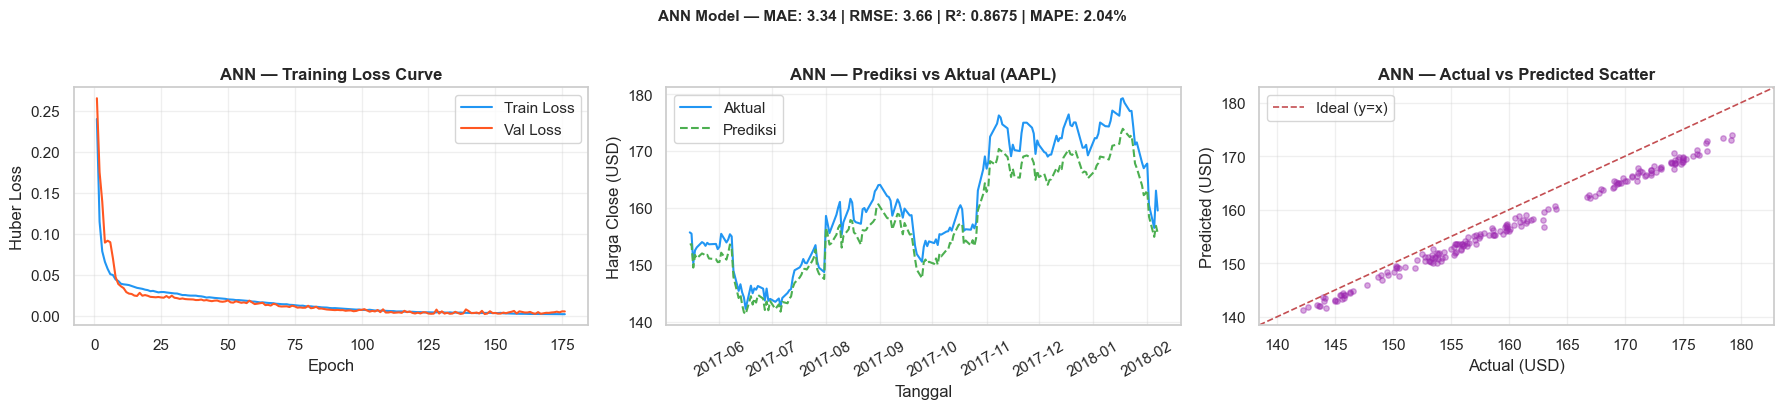

✅ Cell 9b — Grafik tersimpan: docs/ann_results.png


In [9]:
# ── FILE: notebooks/02_modeling.ipynb | CELL 9 (REVISI) ──

# ── Prediksi — TANPA clip karena harga test bisa > train ──
y_pred_ann_sc = ann.predict(X_test_sc, verbose=0).ravel()

print(f"Prediksi scaled min : {y_pred_ann_sc.min():.7f}")
print(f"Prediksi scaled max : {y_pred_ann_sc.max():.7f}")

# Inverse transform langsung tanpa clip
y_pred_ann = scaler_y.inverse_transform(
                 y_pred_ann_sc.reshape(-1, 1)
             ).ravel()

print(f"\nPrediksi min : {y_pred_ann.min():.5f}")
print(f"Prediksi max : {y_pred_ann.max():.5f}")
print(f"Aktual min   : {y_test.min():.2f}")
print(f"Aktual max   : {y_test.max():.2f}")

# ── Metrik ────────────────────────────────────────────────
mae_ann  = mean_absolute_error(y_test, y_pred_ann)
rmse_ann = np.sqrt(mean_squared_error(y_test, y_pred_ann))
r2_ann   = r2_score(y_test, y_pred_ann)
mape_ann = np.mean(np.abs((y_test - y_pred_ann) / y_test)) * 100

print("=" * 38)
print("       ANN — TEST RESULT (v2)")
print("=" * 38)
print(f"   MAE  : {mae_ann:.4f}")
print(f"   RMSE : {rmse_ann:.4f}")
print(f"   R²   : {r2_ann:.4f}")
print(f"   MAPE : {mape_ann:.2f}%")
print("=" * 38)

# Simpan model format .keras (lebih modern dari .h5)
ann.save('../models/ann_model.keras')

results['ANN'] = {
    'MAE' : round(mae_ann,  4),
    'RMSE': round(rmse_ann, 4),
    'R2'  : round(r2_ann,   4),
    'MAPE': round(mape_ann, 2)
}

print("✅ Cell 9 — Model tersimpan: models/ann_model.keras")

# ── FILE: notebooks/02_modeling.ipynb | CELL 9b (TAMBAHAN) ──
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# ── Plot 1: Loss Curve ────────────────────────────────────
epochs_ran = range(1, len(history_ann.history['loss']) + 1)

axes[0].plot(epochs_ran, history_ann.history['loss'],
             label='Train Loss', color='#2196F3', linewidth=1.5)
axes[0].plot(epochs_ran, history_ann.history['val_loss'],
             label='Val Loss',   color='#FF5722', linewidth=1.5)
axes[0].set_title('ANN — Training Loss Curve', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Huber Loss')
axes[0].legend()

# ── Plot 2: Prediksi vs Aktual ────────────────────────────
axes[1].plot(dates_test, y_test,
             label='Aktual',   color='#2196F3', linewidth=1.5)
axes[1].plot(dates_test, y_pred_ann,
             label='Prediksi', color='#4CAF50',
             linewidth=1.5, linestyle='--')
axes[1].set_title(f'ANN — Prediksi vs Aktual ({STOCK})',
                  fontweight='bold')
axes[1].set_xlabel('Tanggal')
axes[1].set_ylabel('Harga Close (USD)')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=30)

# ── Plot 3: Scatter Actual vs Predicted ───────────────────
lims = [
    min(y_test.min(), y_pred_ann.min()) * 0.98,
    max(y_test.max(), y_pred_ann.max()) * 1.02
]
axes[2].scatter(y_test, y_pred_ann,
                alpha=0.4, color='#9C27B0', s=15)
axes[2].plot(lims, lims, 'r--', linewidth=1.2, label='Ideal (y=x)')
axes[2].set_xlim(lims)
axes[2].set_ylim(lims)
axes[2].set_title('ANN — Actual vs Predicted Scatter',
                  fontweight='bold')
axes[2].set_xlabel('Actual (USD)')
axes[2].set_ylabel('Predicted (USD)')
axes[2].legend()

# ── Tambahkan info metrik di judul figure ─────────────────
fig.suptitle(
    f'ANN Model — MAE: {mae_ann:.2f} | RMSE: {rmse_ann:.2f} | '
    f'R²: {r2_ann:.4f} | MAPE: {mape_ann:.2f}%',
    fontsize=11, fontweight='bold', y=1.02
)

plt.tight_layout()
plt.savefig('../docs/ann_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Cell 9b — Grafik tersimpan: docs/ann_results.png")

In [10]:
# ── FILE: notebooks/02_modeling.ipynb | CELL 10 (REVISI) ──
from tensorflow.keras.layers import LSTM, Bidirectional

SEQ_LEN = 10  # turunkan dari 30 → 10 agar lebih stabil

def create_sequences(X, y, seq_len):
    """
    Buat window sekuensial:
    X[i-seq_len:i] → prediksi y[i]
    """
    Xs, ys = [], []
    for i in range(seq_len, len(X)):
        Xs.append(X[i - seq_len : i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

# ── Buat sequence dari masing-masing split ────────────────
# BENAR: sequence dibuat PER split, bukan digabung dulu
# Hal ini mencegah data leakage antar split

# Sequence dari train
Xs_train, ys_train = create_sequences(X_train_sc, y_train_sc, SEQ_LEN)

# Untuk val: gabung ekor train (SEQ_LEN baris) + val
# supaya sequence pertama val tetap valid
X_train_tail = X_train_sc[-SEQ_LEN:]
y_train_tail = y_train_sc[-SEQ_LEN:]

X_val_full = np.vstack([X_train_tail, X_val_sc])
y_val_full  = np.concatenate([y_train_tail, y_val_sc])
Xs_val, ys_val = create_sequences(X_val_full, y_val_full, SEQ_LEN)

# Untuk test: gabung ekor val (SEQ_LEN baris) + test
X_val_tail = X_val_sc[-SEQ_LEN:]
y_val_tail = y_val_sc[-SEQ_LEN:]

X_test_full = np.vstack([X_val_tail, X_test_sc])
y_test_full  = np.concatenate([y_val_tail, y_test_sc])
Xs_test, ys_test = create_sequences(X_test_full, y_test_full, SEQ_LEN)

print(f"SEQ_LEN   : {SEQ_LEN}")
print(f"Xs_train  : {Xs_train.shape}  → (samples, timesteps, features)")
print(f"Xs_val    : {Xs_val.shape}")
print(f"Xs_test   : {Xs_test.shape}")

# Cek range target
print(f"\nys_train  : min={ys_train.min():.4f} | max={ys_train.max():.4f}")
print(f"ys_val    : min={ys_val.min():.4f}   | max={ys_val.max():.4f}")
print(f"ys_test   : min={ys_test.min():.4f}  | max={ys_test.max():.4f}")

print("\n✅ Cell 10 — Data sequence siap (tanpa data leakage)")

SEQ_LEN   : 10
Xs_train  : (858, 10, 15)  → (samples, timesteps, features)
Xs_val    : (186, 10, 15)
Xs_test   : (186, 10, 15)

ys_train  : min=0.0000 | max=1.0000
ys_val    : min=0.6131   | max=1.2992
ys_test   : min=1.1201  | max=1.5991

✅ Cell 10 — Data sequence siap (tanpa data leakage)


In [11]:
# ── FILE: notebooks/02_modeling.ipynb | CELL 11 (REVISI) ──
from tensorflow.keras.regularizers import l2

tf.random.set_seed(42)
np.random.seed(42)

n_features = Xs_train.shape[2]  # jumlah fitur

lstm_model = Sequential([
    Input(shape=(SEQ_LEN, n_features)),

    LSTM(128, return_sequences=True,
         kernel_regularizer=l2(1e-4),
         recurrent_regularizer=l2(1e-4)),
    Dropout(0.2),

    LSTM(64, return_sequences=False,
         kernel_regularizer=l2(1e-4)),
    Dropout(0.2),

    Dense(32, activation='relu'),
    Dense(1,  activation='linear')
], name='LSTM_Model_v2')

lstm_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='huber',        # konsisten dengan ANN, robust terhadap outlier
    metrics=['mae']
)

lstm_model.summary()

callbacks_lstm = [
    EarlyStopping(
        monitor='val_loss',
        patience=30,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        patience=15,
        factor=0.3,
        min_lr=1e-7,
        verbose=1
    )
]

history_lstm = lstm_model.fit(
    Xs_train, ys_train,
    validation_data=(Xs_val, ys_val),
    epochs=500,
    batch_size=16,
    callbacks=callbacks_lstm,
    verbose=1
)

print(f"\n✅ Cell 11 — LSTM training selesai")
print(f"   Epoch berjalan : {len(history_lstm.history['loss'])}")
print(f"   Best val_loss  : {min(history_lstm.history['val_loss']):.6f}")

Model: "LSTM_Model_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10, 128)        │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 10, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 125,249 (489.25 KB)

 Trainable params: 125,249 (489.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0396 - mae: 0.1070 - val_loss: 0.0264 - val_mae: 0.0675 - learning_rate: 0.0010
Epoch 2/500
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0214 - mae: 0.0509 - val_loss: 0.0192 - val_mae: 0.0651 - learning_rate: 0.0010
Epoch 3/500
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0162 - mae: 0.0511 - val_loss: 0.0131 - val_mae: 0.0357 - learning_rate: 0.0010
Epoch 4/500
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0129 - mae: 0.0482 - val_loss: 0.0117 - val_mae: 0.0499 - learning_rate: 0.0010
Epoch 5/500
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0107 - mae: 0.0463 - val_loss: 0.0103 - val_mae: 0.0556 - learning_rate: 0.0010
Epoch 6/500
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0093 - mae: 0.0459 - val_loss: 0.0142 - val_mae: 0.1078 - learning_rate: 0.0010
Epoch 7/500
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0083 - mae: 0.0475 - val_loss: 0.0091 - val_mae: 0.0676 - learning_rate: 0.0010
Epoch 8/500


In [12]:
# ── FILE: notebooks/02_modeling.ipynb | CELL 12 (REVISI) ──

# ── Prediksi — TANPA clip ─────────────────────────────────
y_pred_lstm_sc = lstm_model.predict(Xs_test, verbose=0).ravel()

print(f"Prediksi scaled min : {y_pred_lstm_sc.min():.6f}")
print(f"Prediksi scaled max : {y_pred_lstm_sc.max():.6f}")
print(f"Target  scaled min  : {ys_test.min():.6f}")
print(f"Target  scaled max  : {ys_test.max():.6f}")

# Inverse transform ke harga asli
y_pred_lstm = scaler_y.inverse_transform(
                  y_pred_lstm_sc.reshape(-1, 1)
              ).ravel()

y_test_lstm = scaler_y.inverse_transform(
                  ys_test.reshape(-1, 1)
              ).ravel()

print(f"\nPrediksi min : {y_pred_lstm.min():.2f}")
print(f"Prediksi max : {y_pred_lstm.max():.2f}")
print(f"Aktual min   : {y_test_lstm.min():.2f}")
print(f"Aktual max   : {y_test_lstm.max():.2f}")

# ── Metrik ────────────────────────────────────────────────
mae_lstm  = mean_absolute_error(y_test_lstm, y_pred_lstm)
rmse_lstm = np.sqrt(mean_squared_error(y_test_lstm, y_pred_lstm))
r2_lstm   = r2_score(y_test_lstm, y_pred_lstm)
mape_lstm = np.mean(np.abs((y_test_lstm - y_pred_lstm) / y_test_lstm)) * 100

print("=" * 38)
print("      LSTM — TEST RESULT (v2)")
print("=" * 38)
print(f"   MAE  : {mae_lstm:.4f}")
print(f"   RMSE : {rmse_lstm:.4f}")
print(f"   R²   : {r2_lstm:.4f}")
print(f"   MAPE : {mape_lstm:.2f}%")
print("=" * 38)

# Simpan model format .keras
lstm_model.save('../models/lstm_model.keras')
joblib.dump(SEQ_LEN, '../models/seq_len.pkl')

results['LSTM'] = {
    'MAE' : round(mae_lstm,  4),
    'RMSE': round(rmse_lstm, 4),
    'R2'  : round(r2_lstm,   4),
    'MAPE': round(mape_lstm, 2)
}

print("✅ Cell 12 — Model tersimpan: models/lstm_model.keras")
print("✅ SEQ_LEN tersimpan        : models/seq_len.pkl")

Prediksi scaled min : 1.119664
Prediksi scaled max : 1.500527
Target  scaled min  : 1.120062
Target  scaled max  : 1.599144

Prediksi min : 142.24
Prediksi max : 171.65
Aktual min   : 142.27
Aktual max   : 179.26
      LSTM — TEST RESULT (v2)
   MAE  : 4.2677
   RMSE : 4.9658
   R²   : 0.7563
   MAPE : 2.60%
✅ Cell 12 — Model tersimpan: models/lstm_model.keras
✅ SEQ_LEN tersimpan        : models/seq_len.pkl


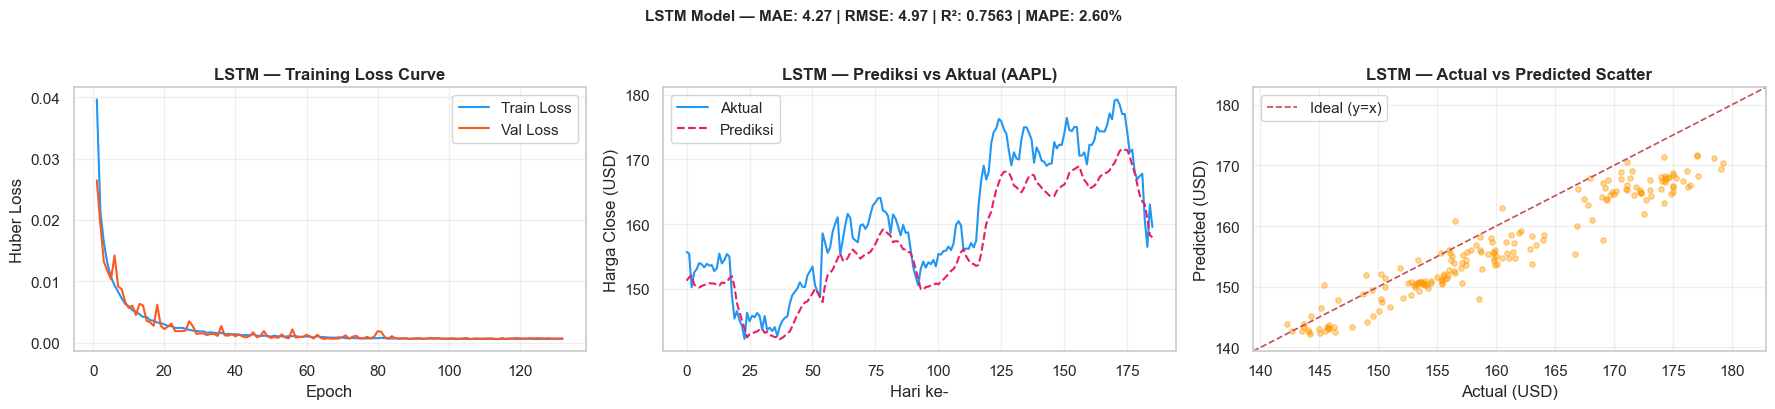

✅ Cell 13 — Grafik tersimpan: docs/lstm_results.png


In [13]:
# ── FILE: notebooks/02_modeling.ipynb | CELL 13 (REVISI) ──
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# ── Plot 1: Loss Curve ────────────────────────────────────
epochs_ran = range(1, len(history_lstm.history['loss']) + 1)

axes[0].plot(epochs_ran, history_lstm.history['loss'],
             label='Train Loss', color='#2196F3', linewidth=1.5)
axes[0].plot(epochs_ran, history_lstm.history['val_loss'],
             label='Val Loss',   color='#FF5722', linewidth=1.5)
axes[0].set_title('LSTM — Training Loss Curve', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Huber Loss')
axes[0].legend()

# ── Plot 2: Prediksi vs Aktual ────────────────────────────
idx_lstm = range(len(y_test_lstm))

axes[1].plot(idx_lstm, y_test_lstm,
             label='Aktual',   color='#2196F3', linewidth=1.5)
axes[1].plot(idx_lstm, y_pred_lstm,
             label='Prediksi', color='#E91E63',
             linewidth=1.5, linestyle='--')
axes[1].set_title(f'LSTM — Prediksi vs Aktual ({STOCK})',
                  fontweight='bold')
axes[1].set_xlabel('Hari ke-')
axes[1].set_ylabel('Harga Close (USD)')
axes[1].legend()

# ── Plot 3: Scatter Actual vs Predicted ───────────────────
lims = [
    min(y_test_lstm.min(), y_pred_lstm.min()) * 0.98,
    max(y_test_lstm.max(), y_pred_lstm.max()) * 1.02
]
axes[2].scatter(y_test_lstm, y_pred_lstm,
                alpha=0.4, color='#FF9800', s=15)
axes[2].plot(lims, lims, 'r--', linewidth=1.2, label='Ideal (y=x)')
axes[2].set_xlim(lims)
axes[2].set_ylim(lims)
axes[2].set_title('LSTM — Actual vs Predicted Scatter',
                  fontweight='bold')
axes[2].set_xlabel('Actual (USD)')
axes[2].set_ylabel('Predicted (USD)')
axes[2].legend()

fig.suptitle(
    f'LSTM Model — MAE: {mae_lstm:.2f} | RMSE: {rmse_lstm:.2f} | '
    f'R²: {r2_lstm:.4f} | MAPE: {mape_lstm:.2f}%',
    fontsize=11, fontweight='bold', y=1.02
)

plt.tight_layout()
plt.savefig('../docs/lstm_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Cell 13 — Grafik tersimpan: docs/lstm_results.png")

In [14]:
# ── FILE: notebooks/02_modeling.ipynb | CELL 14 ───────────
from sklearn.cluster import KMeans
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import joblib

# Pastikan data urut berdasarkan tanggal
data = data.sort_values("date").reset_index(drop=True)

# ── Fitur teknikal untuk clustering ───────────────────────
data["return_5d"]   = data["close"].pct_change(5)
data["return_10d"]  = data["close"].pct_change(10)
data["return_20d"]  = data["close"].pct_change(20)

data["vol_ratio"]   = data["volatility"] / data["close"]
data["range_ratio"] = data["price_range"] / data["close"]

data["ma_gap_5_20"] = (data["MA5"] - data["MA20"]) / data["close"]

# Hindari infinite value
data = data.replace([np.inf, -np.inf], np.nan)

CLUSTER_FEATURES = [
    "RSI",
    "return_5d",
    "return_10d",
    "return_20d",
    "vol_ratio",
    "range_ratio",
    "ma_gap_5_20"
]

X_cluster = data[CLUSTER_FEATURES].dropna().copy()

# Sinkronkan data agar panjangnya sama dengan X_cluster
data_cluster = data.loc[X_cluster.index].copy().reset_index(drop=True)
X_cluster = X_cluster.reset_index(drop=True)

print("Missing values:")
print(X_cluster.isnull().sum())
print(f"\nShape X_cluster   : {X_cluster.shape}")
print(f"Shape data_cluster: {data_cluster.shape}")

# RobustScaler lebih aman untuk data saham yang punya outlier
scaler_cluster = RobustScaler()
X_cluster_sc = scaler_cluster.fit_transform(X_cluster)

joblib.dump(scaler_cluster, "../models/scaler_cluster.pkl")
joblib.dump(CLUSTER_FEATURES, "../models/cluster_features.pkl")

print("\n✅ Cell 14 — Fitur cluster siap")
print(f"✅ Fitur yang digunakan: {CLUSTER_FEATURES}")

Missing values:
RSI            0
return_5d      0
return_10d     0
return_20d     0
vol_ratio      0
range_ratio    0
ma_gap_5_20    0
dtype: int64

Shape X_cluster   : (1220, 7)
Shape data_cluster: (1220, 24)

✅ Cell 14 — Fitur cluster siap
✅ Fitur yang digunakan: ['RSI', 'return_5d', 'return_10d', 'return_20d', 'vol_ratio', 'range_ratio', 'ma_gap_5_20']


In [15]:
# ── FILE: notebooks/02_modeling.ipynb | CELL 15 ───────────
inertia_list = []
silhouette_list = []
K_range = range(2, 11)

print("Menghitung K optimal...\n")

for k in K_range:
    km = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=50,
        max_iter=1000,
        random_state=42
    )

    labels = km.fit_predict(X_cluster_sc)

    inertia_list.append(km.inertia_)

    sil = silhouette_score(
        X_cluster_sc,
        labels,
        sample_size=min(1000, len(X_cluster_sc)),
        random_state=42
    )

    silhouette_list.append(sil)

    print(
        f"K={k:2d} | Inertia: {km.inertia_:>10,.2f} | "
        f"Silhouette: {sil:.4f}"
    )

best_k_sil = list(K_range)[int(np.argmax(silhouette_list))]
score_k3 = silhouette_list[list(K_range).index(3)]

print(f"\n→ K terbaik dari Silhouette: {best_k_sil} "
      f"(score={max(silhouette_list):.4f})")

print(f"→ Score khusus K=3       : {score_k3:.4f}")

print("\n✅ Cell 15 — Selesai")

Menghitung K optimal...

K= 2 | Inertia:   3,965.76 | Silhouette: 0.3027
K= 3 | Inertia:   3,029.56 | Silhouette: 0.2912
K= 4 | Inertia:   2,635.23 | Silhouette: 0.2297
K= 5 | Inertia:   2,398.82 | Silhouette: 0.2230
K= 6 | Inertia:   2,176.06 | Silhouette: 0.2133
K= 7 | Inertia:   2,006.28 | Silhouette: 0.2115
K= 8 | Inertia:   1,873.61 | Silhouette: 0.2100
K= 9 | Inertia:   1,755.51 | Silhouette: 0.2146
K=10 | Inertia:   1,652.32 | Silhouette: 0.1840

→ K terbaik dari Silhouette: 2 (score=0.3027)
→ Score khusus K=3       : 0.2912

✅ Cell 15 — Selesai


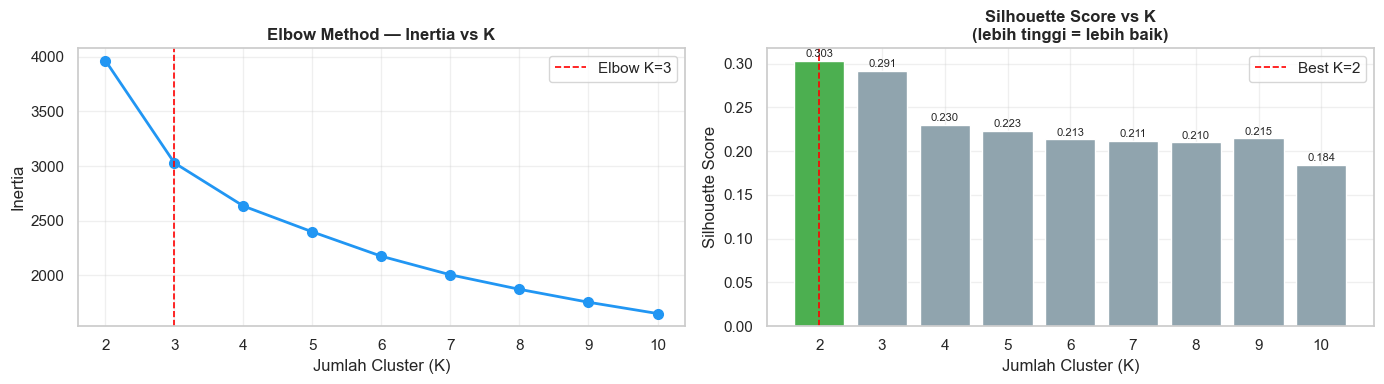


→ Pilih K_OPTIMAL = 2 untuk Cell 17
✅ Cell 16 — Grafik tersimpan: docs/kmeans_elbow.png


In [16]:
# ── FILE: notebooks/02_modeling.ipynb | CELL 16 (REVISI) ──
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ── Plot 1: Elbow ─────────────────────────────────────────
axes[0].plot(list(K_range), inertia_list,
             marker='o', color='#2196F3',
             linewidth=2, markersize=7)
axes[0].set_title('Elbow Method — Inertia vs K',
                  fontweight='bold')
axes[0].set_xlabel('Jumlah Cluster (K)')
axes[0].set_ylabel('Inertia')
axes[0].set_xticks(list(K_range))

# Tandai elbow
best_k_elbow = 3  # sesuaikan setelah lihat grafik
axes[0].axvline(x=best_k_elbow, color='red',
                linestyle='--', linewidth=1.2,
                label=f'Elbow K={best_k_elbow}')
axes[0].legend()

# ── Plot 2: Silhouette ────────────────────────────────────
bar_colors = ['#4CAF50' if i + 2 == best_k_sil
              else '#90A4AE'
              for i in range(len(silhouette_list))]
axes[1].bar(list(K_range), silhouette_list,
            color=bar_colors, edgecolor='white')
axes[1].set_title('Silhouette Score vs K\n(lebih tinggi = lebih baik)',
                  fontweight='bold')
axes[1].set_xlabel('Jumlah Cluster (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(list(K_range))

# Tambah angka di atas bar
for i, (k, s) in enumerate(zip(K_range, silhouette_list)):
    axes[1].text(k, s + 0.002, f'{s:.3f}',
                 ha='center', va='bottom', fontsize=8)

axes[1].axvline(x=best_k_sil, color='red',
                linestyle='--', linewidth=1.2,
                label=f'Best K={best_k_sil}')
axes[1].legend()

plt.tight_layout()
plt.savefig('../docs/kmeans_elbow.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n→ Pilih K_OPTIMAL = {best_k_sil} untuk Cell 17")
print("✅ Cell 16 — Grafik tersimpan: docs/kmeans_elbow.png")

In [17]:
# ── FILE: notebooks/02_modeling.ipynb | CELL 17 ───────────

K_OPTIMAL = 3

kmeans = KMeans(
    n_clusters=K_OPTIMAL,
    init="k-means++",
    n_init=100,
    max_iter=1000,
    random_state=42
)

data_cluster["cluster"] = kmeans.fit_predict(X_cluster_sc)

# ── Profil cluster ────────────────────────────────────────
cluster_profile = data_cluster.groupby("cluster").agg(
    mean_close    = ("close", "mean"),
    mean_return5  = ("return_5d", "mean"),
    mean_return10 = ("return_10d", "mean"),
    mean_return20 = ("return_20d", "mean"),
    mean_rsi      = ("RSI", "mean"),
    mean_vol      = ("volatility", "mean"),
    mean_vol_ratio= ("vol_ratio", "mean"),
    mean_ma_gap   = ("ma_gap_5_20", "mean"),
    count         = ("close", "count")
).round(4)

print("Profil tiap cluster:")
print(cluster_profile.to_string())

# ── Label otomatis untuk K=3 ──────────────────────────────
# Bullish: return_20d paling tinggi
bullish_cluster = cluster_profile["mean_return20"].idxmax()

# Bearish: return_20d paling rendah
bearish_cluster = cluster_profile["mean_return20"].idxmin()

# Sideways: cluster sisanya
sideways_cluster = [
    c for c in cluster_profile.index
    if c not in [bullish_cluster, bearish_cluster]
][0]

label_map = {
    bullish_cluster: "Bullish",
    bearish_cluster: "Bearish",
    sideways_cluster: "Sideways"
}

data_cluster["cluster_label"] = data_cluster["cluster"].map(label_map)

# ── Metrik ────────────────────────────────────────────────
inertia_final = kmeans.inertia_
sil_final = silhouette_score(X_cluster_sc, data_cluster["cluster"])

print("\n" + "=" * 42)
print("     K-MEANS CLUSTERING — RESULT K=3")
print("=" * 42)
print(f"  K (cluster)      : {K_OPTIMAL}")
print(f"  Inertia          : {inertia_final:,.4f}")
print(f"  Silhouette Score : {sil_final:.4f}")
print("=" * 42)

print("\nLabel map:")
print(label_map)

print("\nDistribusi cluster:")
print(data_cluster["cluster_label"].value_counts())

print("\nRata-rata fitur per cluster:")
print(
    data_cluster
    .groupby("cluster_label")[
        ["close", "RSI", "return_5d", "return_20d", "volatility", "vol_ratio", "ma_gap_5_20"]
    ]
    .mean()
    .round(4)
    .to_string()
)

# Simpan model dan pendukungnya
joblib.dump(kmeans, "../models/kmeans_model.pkl")
joblib.dump(label_map, "../models/kmeans_label_map.pkl")
joblib.dump(CLUSTER_FEATURES, "../models/cluster_features.pkl")
joblib.dump(K_OPTIMAL, "../models/k_optimal.pkl")

results["K-Means"] = {
    "MAE": "-",
    "RMSE": "-",
    "R2": "-",
    "MAPE": "-",
    "Inertia": round(inertia_final, 4),
    "Silhouette": round(sil_final, 4)
}

print("\n✅ Cell 17 — Semua file tersimpan")

Profil tiap cluster:
         mean_close  mean_return5  mean_return10  mean_return20  mean_rsi  mean_vol  mean_vol_ratio  mean_ma_gap  count
cluster                                                                                                                
0          102.1339       -0.0331        -0.0565        -0.0650   31.5378    2.7391          0.0274      -0.0354    203
1          109.3897        0.0334         0.0638         0.0834   75.9474    2.4576          0.0228       0.0365    310
2          113.4206        0.0027         0.0038         0.0141   53.3559    1.3581          0.0122       0.0032    707

     K-MEANS CLUSTERING — RESULT K=3
  K (cluster)      : 3
  Inertia          : 3,029.5627
  Silhouette Score : 0.2954

Label map:
{np.int32(1): 'Bullish', np.int32(0): 'Bearish', 2: 'Sideways'}

Distribusi cluster:
cluster_label
Sideways    707
Bullish     310
Bearish     203
Name: count, dtype: int64

Rata-rata fitur per cluster:
                  close      RSI  return_5d

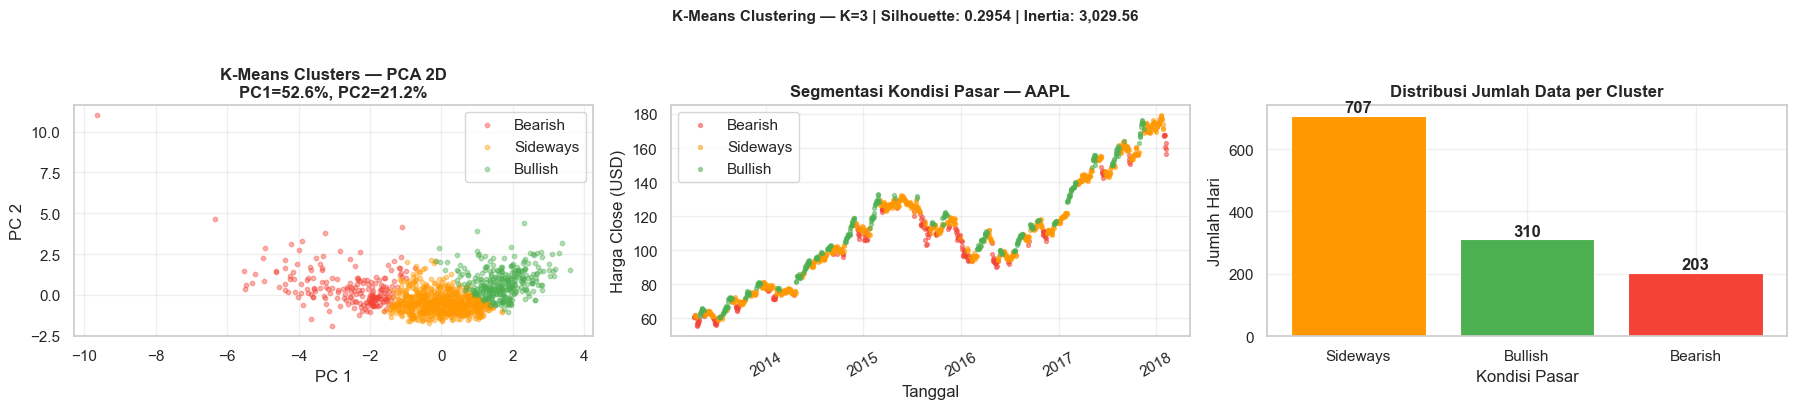

✅ Cell 18 — Grafik tersimpan: docs/kmeans_results.png


In [18]:
# ── FILE: notebooks/02_modeling.ipynb | CELL 18 ───────────

COLORS = {
    "Bearish": "#F44336",
    "Sideways": "#FF9800",
    "Bullish": "#4CAF50"
}

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# ── Plot 1: PCA 2D ────────────────────────────────────────
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster_sc)
var_explained = pca.explained_variance_ratio_ * 100

for label, color in COLORS.items():
    mask = data_cluster["cluster_label"] == label
    axes[0].scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=label,
        color=color,
        alpha=0.4,
        s=10
    )

axes[0].set_title(
    f"K-Means Clusters — PCA 2D\n"
    f"PC1={var_explained[0]:.1f}%, PC2={var_explained[1]:.1f}%",
    fontweight="bold"
)
axes[0].set_xlabel("PC 1")
axes[0].set_ylabel("PC 2")
axes[0].legend()

# ── Plot 2: Harga Close per Cluster ──────────────────────
for label, color in COLORS.items():
    mask = data_cluster["cluster_label"] == label
    axes[1].scatter(
        data_cluster.loc[mask, "date"],
        data_cluster.loc[mask, "close"],
        label=label,
        color=color,
        alpha=0.5,
        s=8
    )

axes[1].set_title(f"Segmentasi Kondisi Pasar — {STOCK}", fontweight="bold")
axes[1].set_xlabel("Tanggal")
axes[1].set_ylabel("Harga Close (USD)")
axes[1].legend()
axes[1].tick_params(axis="x", rotation=30)

# ── Plot 3: Distribusi cluster ────────────────────────────
count_data = data_cluster["cluster_label"].value_counts()
bar_colors = [COLORS.get(l, "#90A4AE") for l in count_data.index]

bars = axes[2].bar(
    count_data.index,
    count_data.values,
    color=bar_colors,
    edgecolor="white",
    linewidth=0.8
)

axes[2].set_title("Distribusi Jumlah Data per Cluster", fontweight="bold")
axes[2].set_xlabel("Kondisi Pasar")
axes[2].set_ylabel("Jumlah Hari")

for bar in bars:
    h = bar.get_height()
    axes[2].text(
        bar.get_x() + bar.get_width() / 2,
        h + 3,
        str(int(h)),
        ha="center",
        va="bottom",
        fontweight="bold"
    )

fig.suptitle(
    f"K-Means Clustering — K={K_OPTIMAL} | "
    f"Silhouette: {sil_final:.4f} | "
    f"Inertia: {inertia_final:,.2f}",
    fontsize=11,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()
plt.savefig("../docs/kmeans_results.png", dpi=150, bbox_inches="tight")
plt.show()

print("✅ Cell 18 — Grafik tersimpan: docs/kmeans_results.png")

In [19]:
# ── FILE: notebooks/02_modeling.ipynb | CELL 19 (REVISI) ──

class NeuralNetworkManual:
    def __init__(self, layer_sizes, learning_rate=0.001,
                 lr_decay=0.995, seed=42):
        """
        layer_sizes  : [input, hidden1, hidden2, ..., output]
        learning_rate: learning rate awal
        lr_decay     : faktor decay per epoch (0.995 = turun 0.5% tiap epoch)
        """
        np.random.seed(seed)
        self.lr_init      = learning_rate
        self.lr           = learning_rate
        self.lr_decay     = lr_decay
        self.layer_sizes  = layer_sizes
        self.weights      = []
        self.biases       = []
        self.loss_history     = []
        self.val_loss_history = []
        self.lr_history       = []

        # ── He initialization ─────────────────────────────
        for i in range(len(layer_sizes) - 1):
            fan_in = layer_sizes[i]
            w = np.random.randn(fan_in, layer_sizes[i + 1]) \
                * np.sqrt(2.0 / fan_in)
            b = np.zeros((1, layer_sizes[i + 1]))
            self.weights.append(w)
            self.biases.append(b)

    # ── Aktivasi ──────────────────────────────────────────
    def relu(self, z):
        return np.maximum(0, z)

    def relu_derivative(self, z):
        return (z > 0).astype(float)

    def leaky_relu(self, z, alpha=0.01):
        return np.where(z > 0, z, alpha * z)

    def leaky_relu_derivative(self, z, alpha=0.01):
        return np.where(z > 0, 1.0, alpha)

    def linear(self, z):
        return z

    # ── Forward Pass ──────────────────────────────────────
    def forward(self, X):
        self.A = [X]
        self.Z = []
        current = X

        for i, (w, b) in enumerate(zip(self.weights, self.biases)):
            z = current @ w + b
            self.Z.append(z)
            if i == len(self.weights) - 1:
                a = self.linear(z)         # output layer → linear
            else:
                a = self.leaky_relu(z)     # hidden → LeakyReLU
            self.A.append(a)
            current = a

        return current

    # ── Loss (Huber) ──────────────────────────────────────
    def compute_loss(self, y_pred, y_true, delta=1.0):
        """
        Huber loss: MAE untuk error besar, MSE untuk error kecil
        Lebih robust terhadap outlier dibanding MSE murni
        """
        r    = y_pred.ravel() - y_true.ravel()
        loss = np.where(
            np.abs(r) <= delta,
            0.5 * r ** 2,
            delta * (np.abs(r) - 0.5 * delta)
        )
        return np.mean(loss)

    def compute_loss_gradient(self, y_pred, y_true, delta=1.0):
        """Gradien Huber loss terhadap prediksi"""
        m = y_true.shape[0]
        r = y_pred.ravel() - y_true.ravel()
        grad = np.where(np.abs(r) <= delta, r, delta * np.sign(r))
        return grad.reshape(-1, 1) / m

    # ── Backward Pass ─────────────────────────────────────
    def backward(self, y_true):
        n_layers = len(self.weights)
        grad_w   = [None] * n_layers
        grad_b   = [None] * n_layers

        # Gradien dari Huber loss
        dA = self.compute_loss_gradient(self.A[-1], y_true)

        for i in reversed(range(n_layers)):
            if i == n_layers - 1:
                dZ = dA  # layer output → linear
            else:
                dZ = dA * self.leaky_relu_derivative(self.Z[i])

            grad_w[i] = self.A[i].T @ dZ
            grad_b[i] = np.sum(dZ, axis=0, keepdims=True)
            dA        = dZ @ self.weights[i].T

        # Gradient clipping → cegah exploding gradient
        max_norm = 5.0
        for i in range(n_layers):
            norm = np.linalg.norm(grad_w[i])
            if norm > max_norm:
                grad_w[i] = grad_w[i] * max_norm / norm

        # Update bobot
        for i in range(n_layers):
            self.weights[i] -= self.lr * grad_w[i]
            self.biases[i]  -= self.lr * grad_b[i]

    # ── Training Loop ─────────────────────────────────────
    def fit(self, X_train, y_train, X_val, y_val,
            epochs=1000, batch_size=32, patience=50,
            verbose=True):

        best_val_loss = np.inf
        best_weights  = None
        best_biases   = None
        no_improve    = 0
        n             = X_train.shape[0]

        for epoch in range(1, epochs + 1):
            # ── Shuffle ───────────────────────────────────
            idx    = np.random.permutation(n)
            X_shuf = X_train[idx]
            y_shuf = y_train[idx]

            # ── Mini-batch gradient descent ───────────────
            for start in range(0, n, batch_size):
                end     = start + batch_size
                X_batch = X_shuf[start:end]
                y_batch = y_shuf[start:end]
                self.forward(X_batch)
                self.backward(y_batch)

            # ── Learning rate decay ───────────────────────
            self.lr = max(self.lr * self.lr_decay, 1e-6)

            # ── Hitung loss ───────────────────────────────
            y_pred_tr  = self.forward(X_train)
            train_loss = self.compute_loss(y_pred_tr, y_train)

            y_pred_val = self.forward(X_val)
            val_loss   = self.compute_loss(y_pred_val, y_val)

            self.loss_history.append(float(train_loss))
            self.val_loss_history.append(float(val_loss))
            self.lr_history.append(self.lr)

            # ── Early stopping ────────────────────────────
            if val_loss < best_val_loss - 1e-7:
                best_val_loss = val_loss
                best_weights  = [w.copy() for w in self.weights]
                best_biases   = [b.copy() for b in self.biases]
                no_improve    = 0
            else:
                no_improve += 1

            if no_improve >= patience:
                if verbose:
                    print(f"\n  Early stopping epoch {epoch} "
                          f"| val_loss: {val_loss:.6f} "
                          f"| lr: {self.lr:.2e}")
                break

            if verbose and epoch % 100 == 0:
                print(f"  Epoch {epoch:5d} "
                      f"| train: {train_loss:.6f} "
                      f"| val: {val_loss:.6f} "
                      f"| lr: {self.lr:.2e}")

        # Restore bobot terbaik
        self.weights = best_weights
        self.biases  = best_biases
        print(f"\n  Best val_loss : {best_val_loss:.6f}")
        print(f"  LR akhir      : {self.lr:.2e}")

    # ── Predict ───────────────────────────────────────────
    def predict(self, X):
        return self.forward(X).ravel()

    # ── Save & Load ───────────────────────────────────────
    def save(self, path):
        payload = {
            'layer_sizes'  : self.layer_sizes,
            'learning_rate': self.lr_init,
            'lr_decay'     : self.lr_decay,
            'weights'      : self.weights,
            'biases'       : self.biases
        }
        joblib.dump(payload, path)

    @staticmethod
    def load(path):
        payload = joblib.load(path)
        model   = NeuralNetworkManual(
            payload['layer_sizes'],
            payload['learning_rate'],
            payload.get('lr_decay', 0.995)
        )
        model.weights = payload['weights']
        model.biases  = payload['biases']
        return model

print("✅ Cell 19 — Class NeuralNetworkManual v2 terdefinisi")
print("   Perubahan: LeakyReLU | Huber Loss | LR Decay | Gradient Clipping")

✅ Cell 19 — Class NeuralNetworkManual v2 terdefinisi
   Perubahan: LeakyReLU | Huber Loss | LR Decay | Gradient Clipping


In [20]:
# ── FILE: notebooks/02_modeling.ipynb | CELL 20 (REVISI) ──
n_input  = X_train_sc.shape[1]

bp_model = NeuralNetworkManual(
    layer_sizes   = [n_input, 128, 64, 32, 1],  # lebih dalam
    learning_rate = 0.01,    # lebih besar di awal, decay akan turunkan
    lr_decay      = 0.998,   # turun 0.2% per epoch → perlahan
    seed          = 42
)

print("Arsitektur Backpropagation Manual v2:")
print(f"  Input   : {n_input} neuron")
print(f"  Hidden1 : 128 neuron (LeakyReLU)")
print(f"  Hidden2 : 64  neuron (LeakyReLU)")
print(f"  Hidden3 : 32  neuron (LeakyReLU)")
print(f"  Output  : 1   neuron (Linear)")
print(f"  Loss        : Huber")
print(f"  LR awal     : 0.01")
print(f"  LR decay    : 0.998 per epoch")
print(f"  Grad clip   : max_norm=5.0")
print(f"\nMulai training...\n")

bp_model.fit(
    X_train_sc, y_train_sc,
    X_val_sc,   y_val_sc,
    epochs     = 2000,
    batch_size = 32,
    patience   = 50,
    verbose    = True
)

print("\n✅ Cell 20 — Training selesai")

Arsitektur Backpropagation Manual v2:
  Input   : 15 neuron
  Hidden1 : 128 neuron (LeakyReLU)
  Hidden2 : 64  neuron (LeakyReLU)
  Hidden3 : 32  neuron (LeakyReLU)
  Output  : 1   neuron (Linear)
  Loss        : Huber
  LR awal     : 0.01
  LR decay    : 0.998 per epoch
  Grad clip   : max_norm=5.0

Mulai training...

  Epoch   100 | train: 0.000201 | val: 0.000148 | lr: 8.19e-03
  Epoch   200 | train: 0.000108 | val: 0.000062 | lr: 6.70e-03
  Epoch   300 | train: 0.000083 | val: 0.000045 | lr: 5.48e-03
  Epoch   400 | train: 0.000073 | val: 0.000042 | lr: 4.49e-03
  Epoch   500 | train: 0.000067 | val: 0.000038 | lr: 3.68e-03
  Epoch   600 | train: 0.000063 | val: 0.000035 | lr: 3.01e-03
  Epoch   700 | train: 0.000060 | val: 0.000034 | lr: 2.46e-03
  Epoch   800 | train: 0.000059 | val: 0.000031 | lr: 2.02e-03
  Epoch   900 | train: 0.000057 | val: 0.000031 | lr: 1.65e-03
  Epoch  1000 | train: 0.000056 | val: 0.000031 | lr: 1.35e-03

  Early stopping epoch 1010 | val_loss: 0.000030

In [21]:
# ── FILE: notebooks/02_modeling.ipynb | CELL 21 (REVISI) ──

# ── Prediksi tanpa clip ───────────────────────────────────
y_pred_bp_sc = bp_model.predict(X_test_sc)

print(f"Prediksi scaled min : {y_pred_bp_sc.min():.6f}")
print(f"Prediksi scaled max : {y_pred_bp_sc.max():.6f}")

y_pred_bp = scaler_y.inverse_transform(
                y_pred_bp_sc.reshape(-1, 1)
            ).ravel()

print(f"\nPrediksi min : {y_pred_bp.min():.2f}")
print(f"Prediksi max : {y_pred_bp.max():.2f}")
print(f"Aktual min   : {y_test.min():.2f}")
print(f"Aktual max   : {y_test.max():.2f}")

# ── Metrik ────────────────────────────────────────────────
mae_bp  = mean_absolute_error(y_test, y_pred_bp)
rmse_bp = np.sqrt(mean_squared_error(y_test, y_pred_bp))
r2_bp   = r2_score(y_test, y_pred_bp)
mape_bp = np.mean(np.abs((y_test - y_pred_bp) / y_test)) * 100

# Convergence epoch: epoch saat val_loss pertama kali
# turun di bawah 10% dari val_loss awal
initial_loss = bp_model.val_loss_history[0]
threshold    = initial_loss * 0.90   # turun 10% dari awal
conv_epoch   = next(
    (i + 1 for i, loss in enumerate(bp_model.val_loss_history)
     if loss < threshold),
    len(bp_model.val_loss_history)
)

print("\n" + "=" * 46)
print("   BACKPROPAGATION MANUAL — TEST RESULT (v2)")
print("=" * 46)
print(f"   MAE              : {mae_bp:.4f}")
print(f"   RMSE             : {rmse_bp:.4f}")
print(f"   R²               : {r2_bp:.4f}")
print(f"   MAPE             : {mape_bp:.2f}%")
print(f"   Convergence Epoch: {conv_epoch}")
print(f"   Total Epoch      : {len(bp_model.loss_history)}")
print("=" * 46)

bp_model.save('../models/backprop_model.pkl')

results['Backpropagation'] = {
    'MAE' : round(mae_bp,  4),
    'RMSE': round(rmse_bp, 4),
    'R2'  : round(r2_bp,   4),
    'MAPE': round(mape_bp, 2)
}

print("✅ Cell 21 — Model tersimpan: models/backprop_model.pkl")

Prediksi scaled min : 1.090204
Prediksi scaled max : 1.594269

Prediksi min : 139.96
Prediksi max : 178.88
Aktual min   : 142.27
Aktual max   : 179.26

   BACKPROPAGATION MANUAL — TEST RESULT (v2)
   MAE              : 1.7348
   RMSE             : 2.0791
   R²               : 0.9573
   MAPE             : 1.07%
   Convergence Epoch: 2
   Total Epoch      : 1010
✅ Cell 21 — Model tersimpan: models/backprop_model.pkl


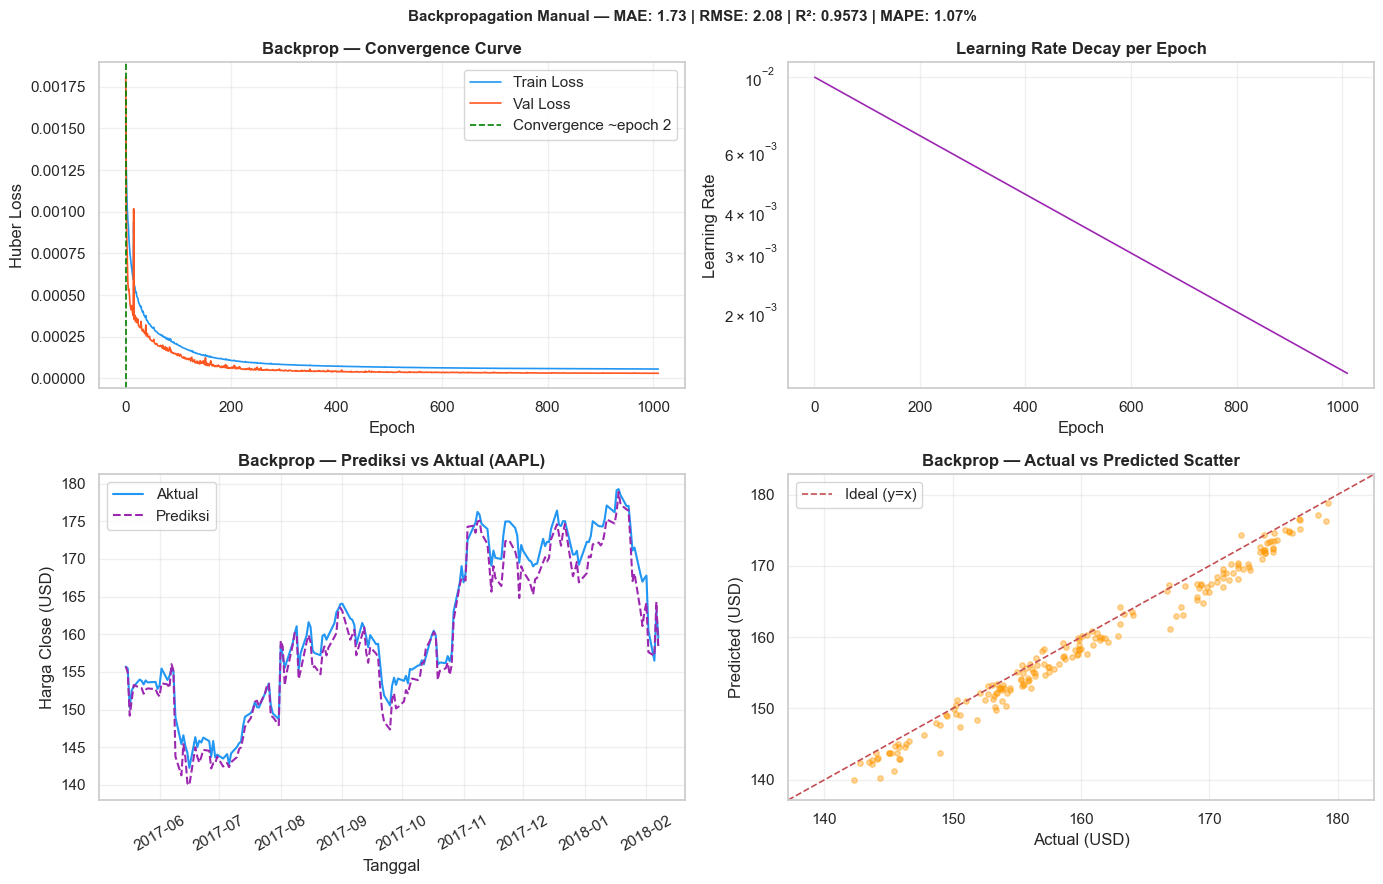

✅ Cell 22 — Grafik tersimpan: docs/backprop_results.png


In [22]:
# ── FILE: notebooks/02_modeling.ipynb | CELL 22 (REVISI) ──
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# ── Plot 1: Loss Curve ────────────────────────────────────
epochs_bp = range(1, len(bp_model.loss_history) + 1)

axes[0,0].plot(epochs_bp, bp_model.loss_history,
               label='Train Loss', color='#2196F3', linewidth=1.2)
axes[0,0].plot(epochs_bp, bp_model.val_loss_history,
               label='Val Loss',   color='#FF5722', linewidth=1.2)
axes[0,0].axvline(x=conv_epoch, color='green', linestyle='--',
                  linewidth=1.2,
                  label=f'Convergence ~epoch {conv_epoch}')
axes[0,0].set_title('Backprop — Convergence Curve',
                    fontweight='bold')
axes[0,0].set_xlabel('Epoch')
axes[0,0].set_ylabel('Huber Loss')
axes[0,0].legend()

# ── Plot 2: Learning Rate Decay ───────────────────────────
axes[0,1].plot(epochs_bp, bp_model.lr_history,
               color='#9C27B0', linewidth=1.2)
axes[0,1].set_title('Learning Rate Decay per Epoch',
                    fontweight='bold')
axes[0,1].set_xlabel('Epoch')
axes[0,1].set_ylabel('Learning Rate')
axes[0,1].set_yscale('log')

# ── Plot 3: Prediksi vs Aktual ────────────────────────────
axes[1,0].plot(dates_test, y_test,
               label='Aktual',   color='#2196F3', linewidth=1.5)
axes[1,0].plot(dates_test, y_pred_bp,
               label='Prediksi', color='#9C27B0',
               linewidth=1.5, linestyle='--')
axes[1,0].set_title(f'Backprop — Prediksi vs Aktual ({STOCK})',
                    fontweight='bold')
axes[1,0].set_xlabel('Tanggal')
axes[1,0].set_ylabel('Harga Close (USD)')
axes[1,0].legend()
axes[1,0].tick_params(axis='x', rotation=30)

# ── Plot 4: Scatter Actual vs Predicted ───────────────────
lims = [
    min(y_test.min(), y_pred_bp.min()) * 0.98,
    max(y_test.max(), y_pred_bp.max()) * 1.02
]
axes[1,1].scatter(y_test, y_pred_bp,
                  alpha=0.4, color='#FF9800', s=15)
axes[1,1].plot(lims, lims, 'r--',
               linewidth=1.2, label='Ideal (y=x)')
axes[1,1].set_xlim(lims)
axes[1,1].set_ylim(lims)
axes[1,1].set_title('Backprop — Actual vs Predicted Scatter',
                    fontweight='bold')
axes[1,1].set_xlabel('Actual (USD)')
axes[1,1].set_ylabel('Predicted (USD)')
axes[1,1].legend()

fig.suptitle(
    f'Backpropagation Manual — MAE: {mae_bp:.2f} | '
    f'RMSE: {rmse_bp:.2f} | R²: {r2_bp:.4f} | '
    f'MAPE: {mape_bp:.2f}%',
    fontsize=11, fontweight='bold'
)

plt.tight_layout()
plt.savefig('../docs/backprop_results.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Cell 22 — Grafik tersimpan: docs/backprop_results.png")

In [23]:
# ── FILE: notebooks/02_modeling.ipynb | CELL 23 ──────────

# ── Tabel perbandingan ────────────────────────────────────
df_results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'ANN',
        'LSTM',
        'K-Means',
        'Backpropagation'
    ],
    'MAE': [
        results['Linear Regression']['MAE'],
        results['ANN']['MAE'],
        results['LSTM']['MAE'],
        '-',
        results['Backpropagation']['MAE']
    ],
    'RMSE': [
        results['Linear Regression']['RMSE'],
        results['ANN']['RMSE'],
        results['LSTM']['RMSE'],
        '-',
        results['Backpropagation']['RMSE']
    ],
    'R²': [
        results['Linear Regression']['R2'],
        results['ANN']['R2'],
        results['LSTM']['R2'],
        '-',
        results['Backpropagation']['R2']
    ],
    'MAPE (%)': [
        results['Linear Regression']['MAPE'],
        results['ANN']['MAPE'],
        results['LSTM']['MAPE'],
        '-',
        results['Backpropagation']['MAPE']
    ],
    'Catatan Khusus': [
        'Baseline model',
        'Dense multilayer',
        f"Lookback {SEQ_LEN} hari",
        f"K={K_OPTIMAL}, Sil={results['K-Means']['Silhouette']}",
        f"Conv.~epoch {conv_epoch}"
    ]
})

print("=" * 75)
print("          TABEL PERBANDINGAN SEMUA MODEL")
print("=" * 75)
print(df_results.to_string(index=False))
print("=" * 75)

# Simpan ke CSV untuk referensi laporan
df_results.to_csv('../docs/model_comparison.csv', index=False)
print("\n✅ Cell 23 — Tabel tersimpan: docs/model_comparison.csv")

          TABEL PERBANDINGAN SEMUA MODEL
            Model     MAE    RMSE      R² MAPE (%)   Catatan Khusus
Linear Regression  0.3958  0.5673  0.9968     0.24   Baseline model
              ANN  3.3417  3.6617  0.8675     2.04 Dense multilayer
             LSTM  4.2677  4.9658  0.7563      2.6 Lookback 10 hari
          K-Means       -       -       -        -  K=3, Sil=0.2954
  Backpropagation  1.7348  2.0791  0.9573     1.07    Conv.~epoch 2

✅ Cell 23 — Tabel tersimpan: docs/model_comparison.csv


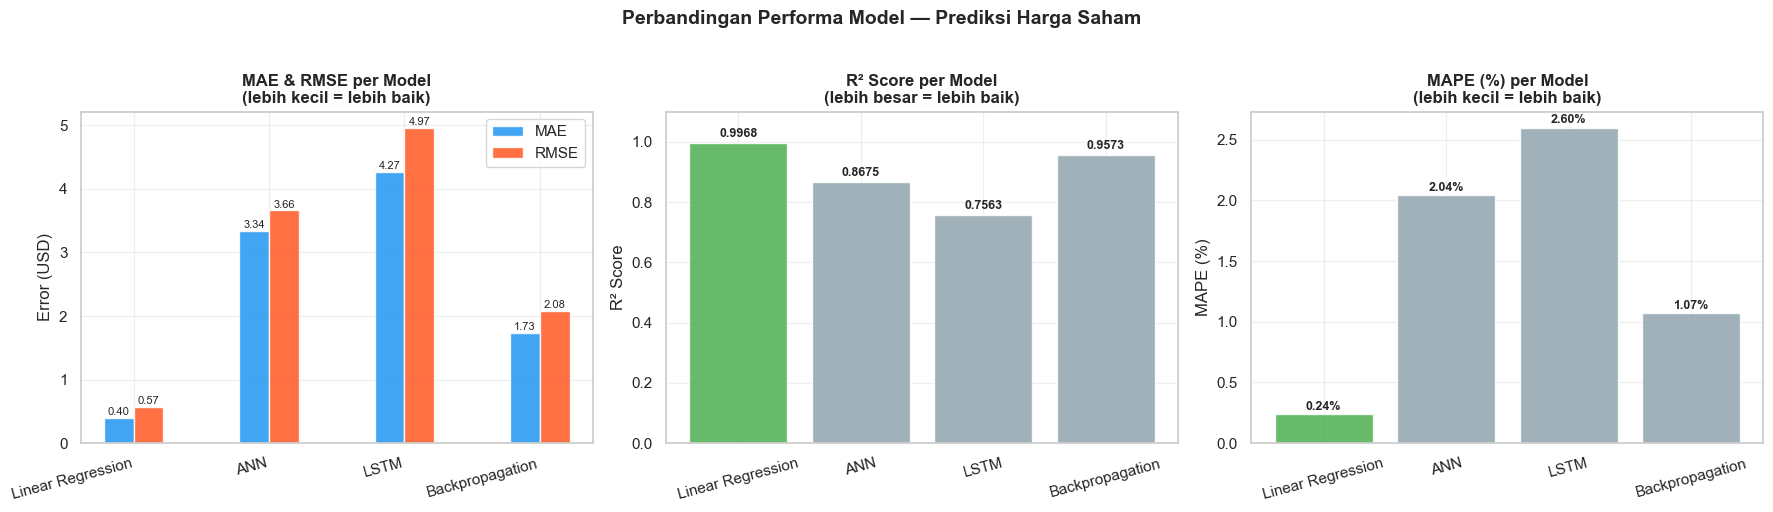

✅ Cell 24 — Grafik tersimpan: docs/model_comparison.png


In [24]:
# ── FILE: notebooks/02_modeling.ipynb | CELL 24 ──────────

# Filter hanya model dengan metrik numerik
models_num  = ['Linear Regression', 'ANN', 'LSTM', 'Backpropagation']
mae_vals    = [results[m]['MAE']  for m in models_num]
rmse_vals   = [results[m]['RMSE'] for m in models_num]
r2_vals     = [results[m]['R2']   for m in models_num]
mape_vals   = [results[m]['MAPE'] for m in models_num]

x     = np.arange(len(models_num))
width = 0.22

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Plot 1: MAE & RMSE (lebih kecil lebih baik) ───────────
bars1 = axes[0].bar(x - width/2, mae_vals,  width,
                    label='MAE',  color='#2196F3', alpha=0.85)
bars2 = axes[0].bar(x + width/2, rmse_vals, width,
                    label='RMSE', color='#FF5722', alpha=0.85)
axes[0].set_title('MAE & RMSE per Model\n(lebih kecil = lebih baik)',
                  fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models_num, rotation=15, ha='right')
axes[0].set_ylabel('Error (USD)')
axes[0].legend()

for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f'{bar.get_height():.2f}',
                 ha='center', va='bottom', fontsize=8)
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f'{bar.get_height():.2f}',
                 ha='center', va='bottom', fontsize=8)

# ── Plot 2: R² Score (lebih besar lebih baik) ────────────
colors_r2 = ['#4CAF50' if v == max(r2_vals)
              else '#90A4AE' for v in r2_vals]
bars3 = axes[1].bar(models_num, r2_vals,
                    color=colors_r2, alpha=0.85,
                    edgecolor='white')
axes[1].set_title('R² Score per Model\n(lebih besar = lebih baik)',
                  fontweight='bold')
axes[1].set_ylabel('R² Score')
axes[1].set_ylim(0, 1.1)
axes[1].tick_params(axis='x', rotation=15)

for bar in bars3:
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f'{bar.get_height():.4f}',
                 ha='center', va='bottom', fontsize=9,
                 fontweight='bold')

# ── Plot 3: MAPE % (lebih kecil lebih baik) ───────────────
colors_mape = ['#4CAF50' if v == min(mape_vals)
               else '#90A4AE' for v in mape_vals]
bars4 = axes[2].bar(models_num, mape_vals,
                    color=colors_mape, alpha=0.85,
                    edgecolor='white')
axes[2].set_title('MAPE (%) per Model\n(lebih kecil = lebih baik)',
                  fontweight='bold')
axes[2].set_ylabel('MAPE (%)')
axes[2].tick_params(axis='x', rotation=15)

for bar in bars4:
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f'{bar.get_height():.2f}%',
                 ha='center', va='bottom', fontsize=9,
                 fontweight='bold')

plt.suptitle('Perbandingan Performa Model — Prediksi Harga Saham',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../docs/model_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Cell 24 — Grafik tersimpan: docs/model_comparison.png")